<a href="https://colab.research.google.com/github/jedidiahramos/DiscreteMathClustering/blob/main/letter_hypervectors_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hypervector

In [ ]:
import numpy as np
import random
import math
import json
import copy


class Hypervector:
    def __init__(self, dimensionality):
        self.dimensionality = dimensionality
        self.vector = np.zeros(dimensionality, dtype=np.int8)

    def randomize(self):  # RANDOM VECTOR OF 1s AND -1s
        self.vector = np.random.choice([-1, 1], self.dimensionality)

    def bind(self, a, b):
        self.vector = np.multiply(a.vector, b.vector)  # PAIRWISE MULTIPLICATION

    def bundle(self, a, b):
        summed = a.vector + b.vector  # PAIRWISE ADDITION
        self.vector = np.clip(summed, -1, 1)  # KEEP THE SUM WITHIN THE RANGE [-1, 1]

    def shift_left(self, times):  # SHIFT ALL VECTOR ELEMENTS LEFT
        if times > 0: self.vector = np.roll(self.vector, -times)

    def shift_right(self, times):  # SHIFT ALL VECTOR ELEMENTS RIGHT
        if times > 0: self.vector = np.roll(self.vector, times)

    def dot_product_with(self, b):
        return np.dot(self.vector, b.vector)

    def cosine_with(self, b):
        norm_a = np.linalg.norm(self.vector)
        norm_b = np.linalg.norm(b.vector)
        return self.dot_product_with(b) / (norm_a * norm_b)

    def copy_vector(self, b):
        self.vector = np.copy(b.vector)

    def n_gram(self, n, n_vectors):
        first_vector = n_vectors[0]
        n_gram_vector = first_vector
        for i in range(1, n):
            n_vectors[i].shift_right(i)
            n_gram_vector.bind(n_gram_vector, n_vectors[i])
        return n_gram_vector

    def profile(self, seed_vectors, document, n_for_n_grams):
        element_count_minus_n_plus1 = len(document) - n_for_n_grams + 1
        for i in range(element_count_minus_n_plus1):
            # CURRENT N-GRAM
            n_vectors = [Hypervector(self.dimensionality) for x in range(n_for_n_grams)]
            element_found = True
            for j in range(n_for_n_grams):
                element = document[i + j]  # AN ELEMENT CAN BE A LETTER OR WORD
                element_found = True
                if element in seed_vectors:
                    element_vector = seed_vectors[element]
                    n_vectors[j].copy_vector(element_vector)
                else:
                    element_found = False
            if element_found: self.bundle(self, self.n_gram(n_for_n_grams, n_vectors))

Tokenizer

In [ ]:
def insert_token(result, opening_char, token):
    while result[-1] != opening_char:
        result.pop()
    result.pop()
    for token_char in token:
        result.append(token_char)


def tokenize_tuples(text):
    result = []
    stack = []
    for char in text:
        result.append(char)
        if char == '(':
            stack.append(char)
        elif char == ',':
            if stack and stack[-1] == '(':
                stack[-1] = char
        elif char == ')' and stack:
            if stack[-1] == ',':
                insert_token(result, '(', '[tuple]')
            stack.pop()
    return ''.join(result)


def tokenize_relations(text):
    result = []
    stack = []
    for char in text:
        result.append(char)
        if char == '{':
            if stack and stack[-1] != '{' and stack[-1] != ']':
                stack.pop()
            stack.append(char)
        elif stack:
            if (stack[-1] == '{' and char == '[') or \
            (stack[-1] == '[' and char == 't') or \
            (stack[-1] == 't' and char == 'u') or \
            (stack[-1] == 'u' and char == 'p') or \
            (stack[-1] == 'p' and char == 'l') or \
            (stack[-1] == 'l' and char == 'e') or \
            (stack[-1] == 'e' and char == ']'):
                stack[-1] = char
            elif char == '}' and stack[-1] == ']':
                insert_token(result, '{', '[relation]')
                stack.pop()
            elif stack[-1] != '{' and stack[-1] != ']':
                stack.pop()
    return ''.join(result)


def tokenize_sets(text):
    result = []
    stack = []
    for char in text:
        result.append(char)
        if char == '{':
            stack.append(char)
        elif char == '}' and stack:
            insert_token(result, '{', '[set]')
            stack.pop()
    return ''.join(result)


def tokenize_math_questions(text):
    return tokenize_sets(tokenize_relations(tokenize_tuples(text)))

Classifier

In [ ]:
class LetterHypervectorClassifier:
    def __init__(self, corpus_json, tokenizing=False, including_newline=False, including_space_bar=False, dimensionality=10000, n_for_n_grams=1):
        self.tokenizing = tokenizing
        self.including_newline = including_newline
        self.including_space_bar = including_space_bar
        self.dimensionality = dimensionality
        self.n_for_n_grams = n_for_n_grams
        self.alphabet_vectors = {}
        self.corpus_document_count = 0
        self.corpus_json = corpus_json
        self.cleaned_json = None
        self.category_count = 0
        self.category_labels = []
        self.category_vectors = []
        self.document_counts_per_category = []
        self.max_category_document_count = 0
        self.max_outlier_performances = []
        self.best_outlier_documents = []
        self.min_outlier_performances = []
        self.worst_outlier_documents = []
        # SET UP
        self.copy_and_clean_json()
        self.get_and_count_categories()
        self.count_documents_per_category()
        self.fill_alphabet()
        self.randomize_alphabet_vectors()

    def copy_and_clean_json(self):
        self.corpus_json = self.corpus_json
        self.cleaned_json = copy.deepcopy(self.corpus_json)
        if self.tokenizing or not self.including_newline or not self.including_space_bar:
            for category in self.corpus_json:
                category_questions = self.cleaned_json[category]
                question_count = len(category_questions)
                for i in range(question_count):
                    if self.tokenizing:
                        category_questions[i] = tokenize_math_questions(category_questions[i])
                    if not self.including_newline:
                        category_questions[i] = category_questions[i].replace("\n", " ")
                    if not self.including_space_bar:
                        category_questions[i] = category_questions[i].replace(" ", "")
        # COUNT ALL DOCUMENTS
        self.corpus_document_count = 0
        for category in self.corpus_json:
            self.corpus_document_count += len(self.corpus_json[category])

    def add_letter_if_not_yet_added(self, letter):
        if letter not in self.alphabet_vectors:
            self.alphabet_vectors[letter] = Hypervector(self.dimensionality)

    def fill_alphabet(self):
        for category in self.cleaned_json:
            for question in self.cleaned_json[category]:
                for letter in question:
                    self.add_letter_if_not_yet_added(letter)

    def randomize_alphabet_vectors(self):
        for alphabet_vector in self.alphabet_vectors:
            self.alphabet_vectors[alphabet_vector].randomize()

    def resize_alphabet_vectors(self, dimensionality):
        self.dimensionality = dimensionality
        for alphabet_vector in self.alphabet_vectors:
            self.alphabet_vectors[alphabet_vector] = Hypervector(dimensionality)

    def get_and_count_categories(self):
        for category in self.corpus_json:
            self.category_labels.append(category)
        self.category_count = len(self.category_labels)

    def count_documents_per_category(self):
        self.document_counts_per_category = [len(self.cleaned_json[self.category_labels[x]]) for x in range(self.category_count)]
        self.max_category_document_count = max(self.document_counts_per_category)

    def new_corpus_with_old_categories(self, corpus_json):
        i = 0
        for category in corpus_json:
            if category != self.category_labels[i]:
                print("NEW CATEGORIES DO NOT MATCH OLD CATEGORIES!")
                return
            i += 1
        if i != self.category_count:
            print("NEW CATEGORIES DO NOT MATCH OLD CATEGORIES!")
            return
        # ELSE, NEW CORPUS IS ACCEPTABLE
        self.corpus_json = corpus_json
        self.copy_and_clean_json()
        self.count_documents_per_category()

    def profile_each_category(self, profile_document_index_lists, verbose):
        if verbose: print("PROFILING CATEGORIES...")
        self.category_vectors = [Hypervector(self.dimensionality) for x in range(self.category_count)]
        for i in range(self.category_count):
            # CURRENT CATEGORY AND PROFILE VECTOR
            category = self.category_labels[i]
            category_vector = self.category_vectors[i]
            category_vector.vector = np.ones(self.dimensionality, dtype=np.int8)
            # DOCUMENTS TO SAMPLE FOR CURRENT CATEGORY PROFILE
            profile_document_indices = profile_document_index_lists[i]
            profile_document_index_count = len(profile_document_indices)

            for j in range(0, profile_document_index_count):  # PROFILE DOCUMENTS TO THE CURRENT CATEGORY
                # CURRENT DOCUMENT
                profile_document_index = profile_document_indices[j]
                profile_document = self.cleaned_json[category][profile_document_index]
                # VECTOR FOR THE CURRENT DOCUMENT
                additional_profile_vector = Hypervector(self.dimensionality)
                additional_profile_vector.profile(self.alphabet_vectors, profile_document, self.n_for_n_grams)
                additional_profile_vector.shift_right(j)
                category_vector.bind(category_vector, additional_profile_vector)
        if verbose: print("CATEGORIES PROFILED")

    def classify_document(self, original_document, cleaned_document, correct_category_index, verbose):
        if verbose: print("QUESTION:", original_document)
        document_vector = Hypervector(self.dimensionality)
        document_vector.profile(self.alphabet_vectors, cleaned_document, self.n_for_n_grams)
        # SCORE EACH CATEGORY
        dot_product_scores = np.zeros(self.category_count, dtype=np.int64)
        for i in range(self.category_count):
            category = self.category_labels[i]
            category_vector = self.category_vectors[i]
            dot_product_score = document_vector.dot_product_with(category_vector)
            dot_product_scores[i] = dot_product_score
            if verbose: print("\tCATEGORY:", category + "\t\tDOT PRODUCT SCORE:", dot_product_score)
        # COMPARE SCORES
        dot_product_winner = np.argmax(dot_product_scores)
        is_correctly_classified = dot_product_winner == correct_category_index
        if verbose: print("DOT PRODUCT CLASSIFICATION:", self.category_labels[dot_product_winner] + "\t\t" + ("C O R R E C T !" if is_correctly_classified else "W R O N G !"))
        return correct_category_index, dot_product_winner

    def classify_each_document(self, with_confusion_matrix, verbose):
        if verbose:
            print("CLASSIFYING DOCUMENTS...")
            correct_count = 0
        confusion_matrix = None
        correct_counts_per_category = None
        if with_confusion_matrix:
            confusion_matrix = np.zeros((self.category_count, self.category_count), dtype=np.int32)
        else:
          correct_counts_per_category = np.zeros(self.category_count, dtype=np.int32)
        corpus_document_index = 0
        for i in range(self.category_count):
            category = self.category_labels[i]
            original_documents = self.corpus_json[category]
            cleaned_documents = self.cleaned_json[category]
            category_document_count = self.document_counts_per_category[i]
            for j in range(category_document_count):
                original_document = original_documents[j]
                cleaned_document = cleaned_documents[j]
                actual, predicted = self.classify_document(original_document, cleaned_document, i, verbose)
                if actual == predicted:
                    if verbose: correct_count += 1
                    if not with_confusion_matrix: correct_counts_per_category[i] += 1
                if with_confusion_matrix:
                    confusion_matrix[actual][predicted] += 1
                corpus_document_index += 1
                if verbose: print(corpus_document_index, "/", self.corpus_document_count, "QUESTIONS CLASSIFIED\n")
        if verbose:
            print("CORRECT CLASSIFICATION COUNT:", correct_count, "/", self.corpus_document_count)
            print("ACCURACY:", 100 * correct_count / self.corpus_document_count, "%")
        if with_confusion_matrix:
            return confusion_matrix
        else:
            return correct_counts_per_category

    def print_outliers(self):
        print("BEST OUTLIERS:\n")
        for i in range(self.category_count):
            category = self.category_labels[i]
            outlier = self.best_outlier_documents[i]
            print("FOR", category, ":\n" + str(outlier) + ".", self.corpus_json[category][outlier] + "\nACCURACY:", str(100 * self.max_outlier_performances[i] / self.document_counts_per_category[i]) + "%\n")
        print("WORST OUTLIERS:\n")
        for i in range(self.category_count):
            category = self.category_labels[i]
            outlier = self.worst_outlier_documents[i]
            print("FOR", category, ":\n" + str(outlier) + ".", self.corpus_json[category][outlier] + "\nACCURACY:", str(100 * self.min_outlier_performances[i] / self.document_counts_per_category[i]) + "%\n")

    def get_outlier_table(self):
        outlier_table = [[0 for x in range(3)] for y in range(self.category_count)]
        for i in range(self.category_count):
            category = self.category_labels[i]
            outlier_table[i][0] = category
            outlier_table[i][1] = self.corpus_json[category][self.best_outlier_documents[i]]
            outlier_table[i][2] = self.corpus_json[category][self.worst_outlier_documents[i]]
        return outlier_table

    def approximately_optimize_category_profiles(self, verbose):
        profile_document_index_lists = [[0] for x in range(self.category_count)]
        self.max_outlier_performances = np.full(self.category_count, -1, dtype=np.int32)
        self.best_outlier_documents = np.zeros(self.category_count, dtype=np.int32)
        self.min_outlier_performances = np.full(self.category_count, self.max_category_document_count + 1, dtype=np.int32)
        self.worst_outlier_documents = np.zeros(self.category_count, dtype=np.int32)
        for i in range(self.max_category_document_count):
            self.profile_each_category(profile_document_index_lists, False)
            if verbose: print("PROFILE DOCUMENT INDICES:", profile_document_index_lists)
            correct_counts_per_category = self.classify_each_document(False, False)
            if verbose: print("CORRECT CLASSIFICATION COUNTS PER CATEGORY:", correct_counts_per_category, "\n")
            for j in range(self.category_count):
                if correct_counts_per_category[j] > self.max_outlier_performances[j]:
                    self.max_outlier_performances[j] = correct_counts_per_category[j]
                    self.best_outlier_documents[j] = profile_document_index_lists[j][0]
                if correct_counts_per_category[j] < self.min_outlier_performances[j]:
                    self.min_outlier_performances[j] = correct_counts_per_category[j]
                    self.worst_outlier_documents[j] = profile_document_index_lists[j][0]
                # MAINTAIN OR INCREMENT PROFILE DOCUMENT INDEX
                next_profile_document_index = profile_document_index_lists[j][0] + 1
                if next_profile_document_index < self.document_counts_per_category[j]:
                    # INCREMENT
                    profile_document_index_lists[j][0] = next_profile_document_index
        if verbose:
            self.print_outliers()
        # USE BEST PROFILES
        for i in range(self.category_count):
            profile_document_index_lists[i][0] = self.best_outlier_documents[i]
        self.profile_each_category(profile_document_index_lists, False)
        correct_count = sum(self.classify_each_document(False, False))
        #print("ACCURACY: " + str(100 * correct_count / self.corpus_document_count) + " %")
        print("ROUNDED ACCURACY: " + str(round(10000 * correct_count / self.corpus_document_count) / 100) + " %")
        return correct_count

Hyperparameter Optimization

In [ ]:
from google.colab import files
from timeit import default_timer as timer
import pandas as pd
import plotly.graph_objects as go


def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)


def print_json(text_json):
    print(json.dumps(text_json, indent=1))


def print_columns(df, table_name):
    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df.columns), fill_color='paleturquoise'),
        cells=dict(values=[df[col] for col in df.columns], fill_color='lavender')
    )])
    fig.update_layout(title=table_name, autosize=False, width=800)
    fig.show()


def print_rows_and_columns(df, table_name):
    fig = go.Figure(data=[go.Table(
        header=dict(values=[""] + list(df.columns), fill_color='lightblue'),
        cells=dict(values=[df.index] + [df[col] for col in df.columns], fill_color='lavender')
    )])
    fig.update_layout(title=table_name, autosize=False)
    fig.show()


def approximately_optimize_hyperparameters(to_be_tokenized, dataset_name):
    uploaded = files.upload()
    training_data, test_data = list(uploaded.keys())

    questions = load_json(training_data)

    experiment_table = [[0 for x in range(5)] for y in range(25)]
    experiment_columns = ['Experiment Number', 'Dimensionality d', 'n for n-grams', 'Accuracy (%)', 'Time (seconds)']
    accuracy_table = [[0 for x in range(5)] for y in range(5)]
    time_table = [[0 for x in range(5)] for y in range(5)]
    accuracy_time_columns = ['n = 1', 'n = 2', 'n = 3', 'n = 4', 'n = 5']
    accuracy_time_rows = ['d = 5000', 'd = 10000', 'd = 15000', 'd = 20000', 'd = 25000']

    max_correct_count = -1
    optimal_classifier = None

    experiment_number = 0
    for d in range(5000, 25001, 5000):
      for n in range(1, 6):
          print("DIMENSIONALITY:", d, "\tN FOR N-GRAMS:", n)

          classifier = LetterHypervectorClassifier(corpus_json=questions, tokenizing=to_be_tokenized, dimensionality=d, n_for_n_grams=n)

          start = timer()
          correct_classification_count = classifier.approximately_optimize_category_profiles(False)
          end = timer()

          if correct_classification_count > max_correct_count:
              max_correct_count = correct_classification_count
              optimal_classifier = classifier

          rounded_accuracy = round(10000 * correct_classification_count / classifier.corpus_document_count) / 100

          duration = end - start
          #print("ELAPSED TIME:", duration, "s")
          rounded_elapsed_time = round(100 * duration) / 100
          print("ROUNDED ELAPSED TIME:", rounded_elapsed_time, "s\n")

          # RECORD IN TABLES

          experiment_table[experiment_number][0] = experiment_number + 1
          experiment_table[experiment_number][1] = d
          experiment_table[experiment_number][2] = n
          experiment_table[experiment_number][3] = rounded_accuracy
          experiment_table[experiment_number][4] = rounded_elapsed_time

          accuracy_table[(d // 5000) - 1][n - 1] = rounded_accuracy
          time_table[(d // 5000) - 1][n - 1] = rounded_elapsed_time

          experiment_number += 1

    # BEST AND WORST OUTLIERS
    outlier_table = optimal_classifier.get_outlier_table()
    outlier_columns = ['Mathematics Category', 'Best Representative Question', 'Worst Representative Question']

    # DISPLAY TABLES AND CHARTS

    experiment_df = pd.DataFrame(experiment_table, columns=experiment_columns)
    print_columns(experiment_df, dataset_name + ' Experiments')

    accuracy_df = pd.DataFrame(accuracy_table, columns=accuracy_time_columns, index=accuracy_time_rows)
    print_rows_and_columns(accuracy_df, dataset_name + ' Hyperparameter Accuracy')

    fig = go.Figure(data=[go.Surface(z=accuracy_df.values)])
    fig.update_layout(
        title=dataset_name + ' Hyperparameter Accuracy',
        scene=dict(
            xaxis=dict(title='n for n-grams', tickvals=list(range(len(accuracy_df.columns))), ticktext=accuracy_df.columns),
            yaxis=dict(title='Dimensionality d', tickvals=list(range(len(accuracy_df.index))), ticktext=accuracy_df.index),
            zaxis=dict(title='Accuracy (%)')
        )
    )
    fig.show()

    time_df = pd.DataFrame(time_table, columns=accuracy_time_columns, index=accuracy_time_rows)
    print_rows_and_columns(time_df, dataset_name + ' Hyperparameter Time')

    fig = go.Figure(data=[go.Surface(z=time_df.values)])
    fig.update_layout(
        title=dataset_name + ' Hyperparameter Time',
        scene=dict(
            xaxis=dict(title='n for n-grams', tickvals=list(range(len(time_df.columns))), ticktext=time_df.columns),
            yaxis=dict(title='Dimensionality d', tickvals=list(range(len(time_df.index))), ticktext=time_df.index),
            zaxis=dict(title='Time (seconds)')
        )
    )
    fig.show()

    outlier_df = pd.DataFrame(outlier_table, columns=outlier_columns)
    print_columns(outlier_df, dataset_name + ' Best and Worst Outliers')

    # TRY ON TEST DATASET
    questions = load_json(test_data)

    optimal_classifier.new_corpus_with_old_categories(questions)
    test_confusion_matrix = optimal_classifier.classify_each_document(True, False)

    confusion_columns = ['Predicted ' + category for category in optimal_classifier.category_labels]
    confusion_rows = ['Actual ' + category for category in optimal_classifier.category_labels]
    confusion_df = pd.DataFrame(test_confusion_matrix, columns=confusion_columns, index=confusion_rows)
    print_rows_and_columns(confusion_df, dataset_name + ' Test Dataset Confusion Matrix')

    true_positive_counts = [test_confusion_matrix[x][x] for x in range(optimal_classifier.category_count)]
    #print("ACCURACY FOR TEST DATASET:", 100 * correct_classification_count / optimal_classifier.corpus_document_count, "%")
    # ROUNDED
    print("ACCURACY FOR TEST DATASET: " + str(round(10000 * sum(true_positive_counts) / optimal_classifier.corpus_document_count) / 100) + " %")
    for i in range(optimal_classifier.category_count):
        print("FOR " + optimal_classifier.category_labels[i])
        false_positive_count = sum([test_confusion_matrix[x][i] for x in range(optimal_classifier.category_count)]) - true_positive_counts[i]
        precision = true_positive_counts[i] / (true_positive_counts[i] + false_positive_count)
        print("\tPRECISION: " + str(np.round(10000 * precision) / 100) + " %")
        false_negative_count = sum(test_confusion_matrix[i]) - true_positive_counts[i]
        recall = true_positive_counts[i] / (true_positive_counts[i] + false_negative_count)
        print("\tRECALL (SENSITIVITY): " + str(np.round(10000 * recall) / 100) + " %")
        print("\tF1 SCORE: " + str(np.round(100 * 2 * (precision * recall) / (precision + recall)) / 100))
        true_negative_count = optimal_classifier.corpus_document_count - (true_positive_counts[i] + false_positive_count + false_negative_count)
        print("\tSPECIFICITY: " + str(np.round(10000 * true_negative_count / (true_negative_count + false_positive_count)) / 100) + " %")

Classifying Unprocessed Questions

In [ ]:
approximately_optimize_hyperparameters(True, 'Unprocessed Questions')

Saving first_20_math_questions.json to first_20_math_questions (3).json
Saving test_math_questions.json to test_math_questions (3).json
DIMENSIONALITY: 5000 	N FOR N-GRAMS: 1
ROUNDED ACCURACY: 40.0 %
ROUNDED ELAPSED TIME: 7.61 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 2
ROUNDED ACCURACY: 45.0 %
ROUNDED ELAPSED TIME: 18.57 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 3
ROUNDED ACCURACY: 41.25 %
ROUNDED ELAPSED TIME: 27.5 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 4
ROUNDED ACCURACY: 48.75 %
ROUNDED ELAPSED TIME: 37.74 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 5
ROUNDED ACCURACY: 37.5 %
ROUNDED ELAPSED TIME: 47.14 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 1
ROUNDED ACCURACY: 51.25 %
ROUNDED ELAPSED TIME: 12.22 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 2
ROUNDED ACCURACY: 41.25 %
ROUNDED ELAPSED TIME: 28.56 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 3
ROUNDED ACCURACY: 48.75 %
ROUNDED ELAPSED TIME: 42.53 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 4
ROUNDED ACCURACY: 43.75 %
ROUNDED ELAPSED TIME: 56.53 s

D

ACCURACY FOR TEST DATASET: 34.31 %
FOR Sets, Proofs, and Induction
	PRECISION: 11.11 %
	RECALL (SENSITIVITY): 40.0 %
	F1 SCORE: 0.17
	SPECIFICITY: 65.22 %
FOR Formal Logic
	PRECISION: 69.23 %
	RECALL (SENSITIVITY): 64.29 %
	F1 SCORE: 0.67
	SPECIFICITY: 89.19 %
FOR Relations
	PRECISION: 18.75 %
	RECALL (SENSITIVITY): 26.09 %
	F1 SCORE: 0.22
	SPECIFICITY: 67.09 %
FOR Functions
	PRECISION: 87.5 %
	RECALL (SENSITIVITY): 17.07 %
	F1 SCORE: 0.29
	SPECIFICITY: 98.36 %


In [ ]:
import plotly.graph_objects as go

precision = [0.11, 0.69, 0.19, 0.88]
recall = [0.40, 0.64, 0.26, 0.17]
f1 = [0.17, 0.67, 0.22, 0.29]
specificity = [0.65, 0.89, 0.67, 0.98]

# Show classification metrics (in percentages, rounded to 2 decimal places)
metrics_fig = go.Figure(data=[go.Table(
    header=dict(values=["Category", "Precision", "Recall", "F1 Score", "Specificity"],
                fill_color='paleturquoise'),
    cells=dict(values=[
        ['Sets, Proofs, and Induction', 'Formal Logic', 'Relations', 'Functions'],
        [f"{p:.2f}" for p in precision],
        [f"{r:.2f}" for r in recall],
        [f"{f:.2f}" for f in f1],
        [f"{s:.2f}" for s in specificity]
    ],
    fill_color='lavender'))
])
metrics_fig.update_layout(title_text="Hypervectors Unprocessed Questions Test Dataset Evaluation Metrics", autosize=False)
metrics_fig.show()

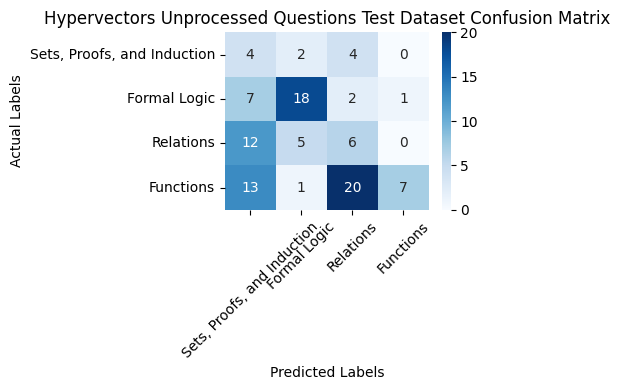

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [ 4,  2,  4,  0],
    [ 7, 18,  2,  1],
    [12,  5,  6,  0],
    [13,  1,  20, 7]
])

# Labels for your classes
labels = ['Sets, Proofs, and Induction', 'Formal Logic', 'Relations', 'Functions']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Hypervectors Unprocessed Questions Test Dataset Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
# Rotate x-axis labels
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

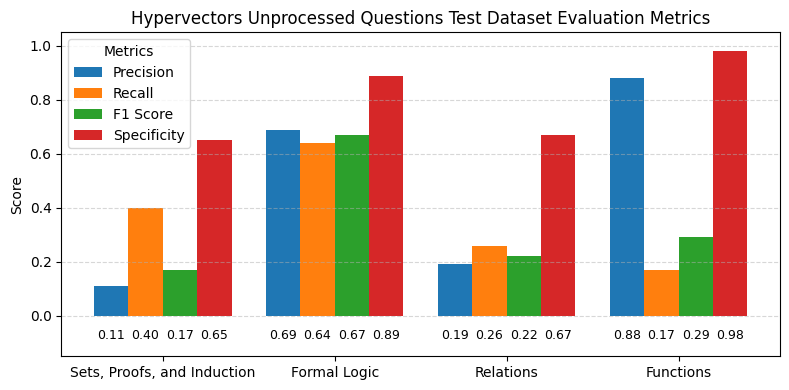

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: 4 classes × 4 metrics
classes = ['Sets, Proofs, and Induction', 'Formal Logic', 'Relations', 'Functions']
metrics = ['Precision', 'Recall', 'F1 Score', 'Specificity']

# Random sample metric values (rows = classes, columns = metrics)
data = np.array([
    [0.11, 0.40, 0.17, 0.65],  # Class A
    [0.69, 0.64, 0.67, 0.89],  # Class B
    [0.19, 0.26, 0.22, 0.67],  # Class C
    [0.88, 0.17, 0.29, 0.98],  # Class D
])

# Plot settings
bar_width = 0.2
x = np.arange(len(classes))  # positions for each group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(8, 4))

# Draw bars and add value labels below each bar (outside the bar)
for i in range(len(metrics)):
    bar_positions = x + i * bar_width
    bars = ax.bar(bar_positions, data[:, i], width=bar_width, label=metrics[i], color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, -0.05, f'{height:.2f}',
                ha='center', va='top', fontsize=9, color='black')

# Axis configuration
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(classes)
ax.set_ylabel('Score')
ax.set_ylim(-0.15, 1.05)  # extra space at bottom to accommodate labels
ax.set_title('Hypervectors Unprocessed Questions Test Dataset Evaluation Metrics')
ax.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

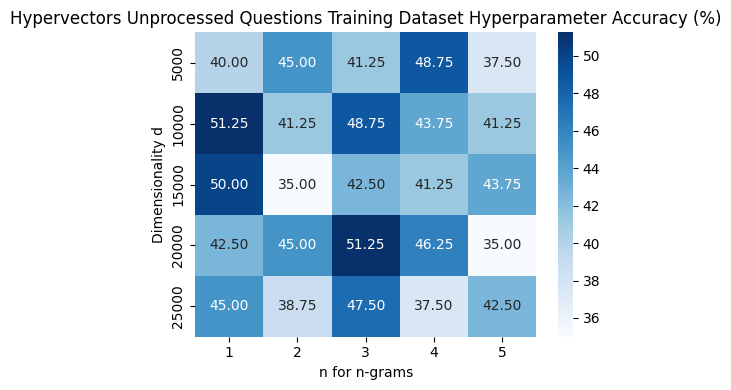

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [40.00, 45.00, 41.25, 48.75, 37.50],
    [51.25, 41.25, 48.75, 43.75, 41.25],
    [50.00, 35.00, 42.50, 41.25, 43.75],
    [42.50, 45.00, 51.25, 46.25, 35.00],
    [45.00, 38.75, 47.50, 37.50, 42.50]
])

# Labels for your classes
xlabels = ['1', '2', '3', '4', '5']
ylabels = ['5000', '10000', '15000', '20000', '25000']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=xlabels, yticklabels=ylabels)
plt.title('Hypervectors Unprocessed Questions Training Dataset Hyperparameter Accuracy (%)')
plt.xlabel('n for n-grams')
plt.ylabel('Dimensionality d')
plt.tight_layout()
plt.show()

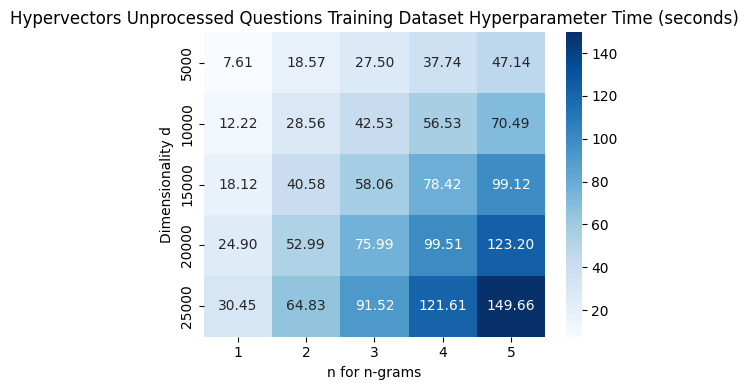

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [ 7.61, 18.57, 27.5, 37.74, 47.14],
    [12.22, 28.56, 42.53, 56.53, 70.49],
    [18.12, 40.58, 58.06, 78.42, 99.12],
    [24.90, 52.99, 75.99, 99.51, 123.20],
    [30.45, 64.83, 91.52, 121.61, 149.66]
])

# Labels for your classes
xlabels = ['1', '2', '3', '4', '5']
ylabels = ['5000', '10000', '15000', '20000', '25000']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=xlabels, yticklabels=ylabels)
plt.title('Hypervectors Unprocessed Questions Training Dataset Hyperparameter Time (seconds)')
plt.xlabel('n for n-grams')
plt.ylabel('Dimensionality d')
plt.tight_layout()
plt.show()

Classifying Processed Questions

In [ ]:
approximately_optimize_hyperparameters(False, 'Processed Questions')

Saving first_20_processed.json to first_20_processed.json
Saving test_processed_questions.json to test_processed_questions.json
DIMENSIONALITY: 5000 	N FOR N-GRAMS: 1
ROUNDED ACCURACY: 38.75 %
ROUNDED ELAPSED TIME: 11.15 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 2
ROUNDED ACCURACY: 46.25 %
ROUNDED ELAPSED TIME: 29.83 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 3
ROUNDED ACCURACY: 48.75 %
ROUNDED ELAPSED TIME: 43.08 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 4
ROUNDED ACCURACY: 38.75 %
ROUNDED ELAPSED TIME: 57.72 s

DIMENSIONALITY: 5000 	N FOR N-GRAMS: 5
ROUNDED ACCURACY: 37.5 %
ROUNDED ELAPSED TIME: 71.89 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 1
ROUNDED ACCURACY: 36.25 %
ROUNDED ELAPSED TIME: 19.52 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 2
ROUNDED ACCURACY: 51.25 %
ROUNDED ELAPSED TIME: 43.7 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 3
ROUNDED ACCURACY: 43.75 %
ROUNDED ELAPSED TIME: 64.24 s

DIMENSIONALITY: 10000 	N FOR N-GRAMS: 4
ROUNDED ACCURACY: 41.25 %
ROUNDED ELAPSED TIME: 88.78 s

DIMENS

ACCURACY FOR TEST DATASET: 36.27 %
FOR Sets, Proofs, and Induction
	PRECISION: 0.0 %
	RECALL (SENSITIVITY): 0.0 %
	F1 SCORE: nan
	SPECIFICITY: 89.13 %
FOR Formal Logic
	PRECISION: 46.43 %
	RECALL (SENSITIVITY): 46.43 %
	F1 SCORE: 0.46
	SPECIFICITY: 79.73 %
FOR Relations
	PRECISION: 23.81 %
	RECALL (SENSITIVITY): 43.48 %
	F1 SCORE: 0.31
	SPECIFICITY: 59.49 %
FOR Functions
	PRECISION: 63.64 %
	RECALL (SENSITIVITY): 34.15 %
	F1 SCORE: 0.44
	SPECIFICITY: 86.89 %


<ipython-input-60-a2707a9a7376>:148: RuntimeWarning:

invalid value encountered in scalar divide



In [ ]:
import plotly.graph_objects as go

precision = [0.00, 0.46, 0.24, 0.64]
recall = [0.00, 0.46, 0.43, 0.34]
f1 = ['nan', 0.46, 0.31, 0.44]
specificity = [0.89, 0.80, 0.59, 0.87]

# Show classification metrics (in percentages, rounded to 2 decimal places)
metrics_fig = go.Figure(data=[go.Table(
    header=dict(values=["Category", "Precision", "Recall", "F1 Score", "Specificity"],
                fill_color='paleturquoise'),
    cells=dict(values=[
        ['Sets, Proofs, and Induction', 'Formal Logic', 'Relations', 'Functions'],
        [f"{p:.2f}" for p in precision],
        [f"{r:.2f}" for r in recall],
        [f"{f}" for f in f1],
        [f"{s:.2f}" for s in specificity]
    ],
    fill_color='lavender'))
])
metrics_fig.update_layout(title_text="Hypervectors Processed Questions Test Dataset Evaluation Metrics", autosize=False)
metrics_fig.show()

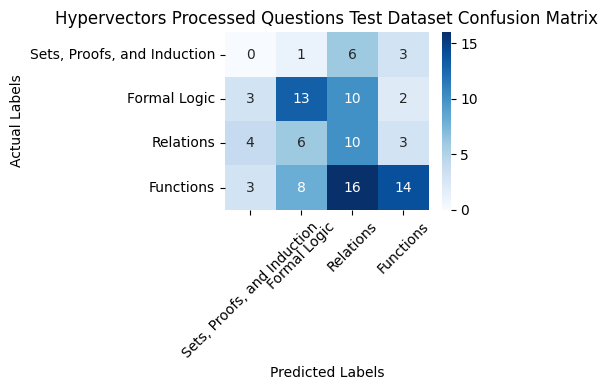

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [ 0,  1,  6,  3],
    [ 3, 13, 10,  2],
    [ 4,  6, 10,  3],
    [ 3,  8,  16,14]
])

# Labels for your classes
labels = ['Sets, Proofs, and Induction', 'Formal Logic', 'Relations', 'Functions']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Hypervectors Processed Questions Test Dataset Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
# Rotate x-axis labels
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

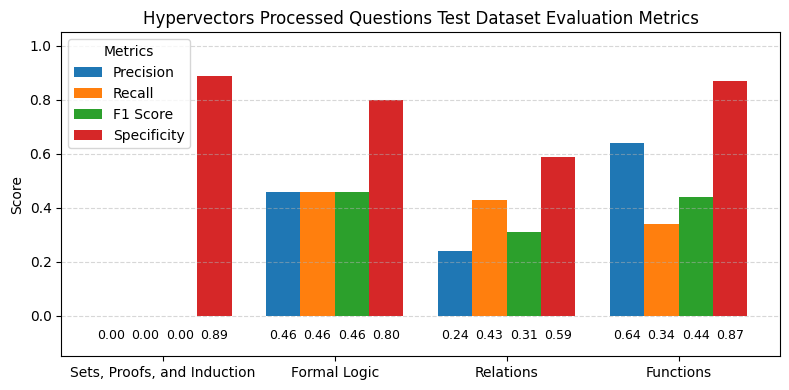

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: 4 classes × 4 metrics
classes = ['Sets, Proofs, and Induction', 'Formal Logic', 'Relations', 'Functions']
metrics = ['Precision', 'Recall', 'F1 Score', 'Specificity']

# Random sample metric values (rows = classes, columns = metrics)
data = np.array([
    [0.00, 0.00, 0.00, 0.89],  # Class A
    [0.46, 0.46, 0.46, 0.80],  # Class B
    [0.24, 0.43, 0.31, 0.59],  # Class C
    [0.64, 0.34, 0.44, 0.87],  # Class D
])

# Plot settings
bar_width = 0.2
x = np.arange(len(classes))  # positions for each group
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(8, 4))

# Draw bars and add value labels below each bar (outside the bar)
for i in range(len(metrics)):
    bar_positions = x + i * bar_width
    bars = ax.bar(bar_positions, data[:, i], width=bar_width, label=metrics[i], color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, -0.05, f'{height:.2f}',
                ha='center', va='top', fontsize=9, color='black')

# Axis configuration
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(classes)
ax.set_ylabel('Score')
ax.set_ylim(-0.15, 1.05)  # extra space at bottom to accommodate labels
ax.set_title('Hypervectors Processed Questions Test Dataset Evaluation Metrics')
ax.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

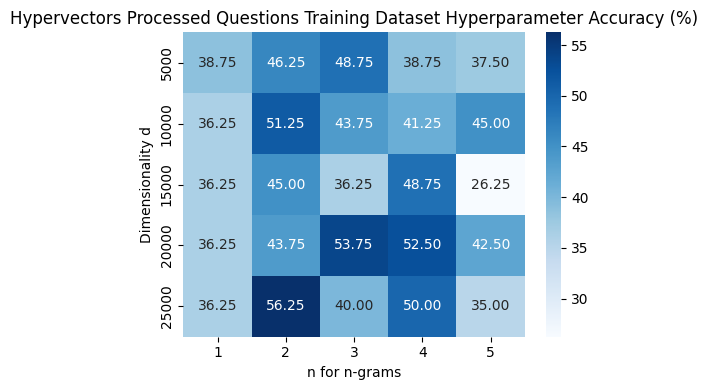

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [38.75, 46.25, 48.75, 38.75, 37.50],
    [36.25, 51.25, 43.75, 41.25, 45.00],
    [36.25, 45.00, 36.25, 48.75, 26.25],
    [36.25, 43.75, 53.75, 52.50, 42.50],
    [36.25, 56.25, 40.00, 50.00, 35.00]
])

# Labels for your classes
xlabels = ['1', '2', '3', '4', '5']
ylabels = ['5000', '10000', '15000', '20000', '25000']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=xlabels, yticklabels=ylabels)
plt.title('Hypervectors Processed Questions Training Dataset Hyperparameter Accuracy (%)')
plt.xlabel('n for n-grams')
plt.ylabel('Dimensionality d')
plt.tight_layout()
plt.show()

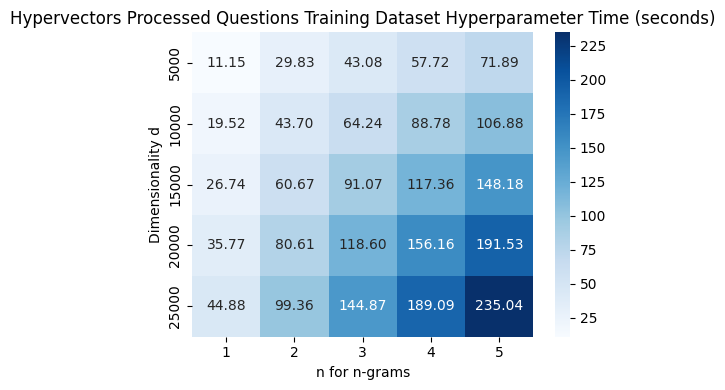

In [ ]:
# Install seaborn if not already installed (uncomment below if needed)
# !pip install seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Sample 4x4 confusion matrix (you can replace this with your actual matrix)
conf_matrix = np.array([
    [11.15, 29.83, 43.08, 57.72, 71.89],
    [19.52, 43.70, 64.24, 88.78, 106.88],
    [26.74, 60.67, 91.07, 117.36, 148.18],
    [35.77, 80.61, 118.60, 156.16, 191.53],
    [44.88, 99.36, 144.87, 189.09, 235.04]
])

# Labels for your classes
xlabels = ['1', '2', '3', '4', '5']
ylabels = ['5000', '10000', '15000', '20000', '25000']

# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=xlabels, yticklabels=ylabels)
plt.title('Hypervectors Processed Questions Training Dataset Hyperparameter Time (seconds)')
plt.xlabel('n for n-grams')
plt.ylabel('Dimensionality d')
plt.tight_layout()
plt.show()